In [1]:
# importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_segmented = pd.read_csv("../data/customer_segmented.csv")
df_segmented

,customer_id,channel,cost,conversion_rate,revenue,net_value,customer_segment
0,1,referral,8.320327,0.123145,4199,4190.680,High Value
1,2,paid advertising,30.450327,0.016341,3410,3379.550,Medium Value
2,3,email marketing,5.246263,0.043822,3164,3158.754,Medium Value
3,4,social media,9.546326,0.167592,1520,1510.454,Low Value
4,5,referral,8.320327,0.123145,2419,2410.680,Medium Value
...,...,...,...,...,...,...,...
795,796,social media,9.546326,0.167592,2813,2803.454,Medium Value
796,797,email marketing,5.246263,0.043822,3439,3433.754,Medium Value
797,798,social media,9.546326,0.167592,2101,2091.454,Medium Value
798,799,paid advertising,30.450327,0.016341,813,782.550,Low Value


In [3]:
# principales estadísticas por segmento de clientes
df_segmented.groupby("customer_segment")[
    ["revenue", "net_value", "cost", "conversion_rate"]
].agg(["mean", "median", "count"])

revenue                  net_value                  \
                       mean  median count         mean    median count   
customer_segment                                                         
High Value        4385.2750  4380.5   200  4371.091470  4371.567   200   
Low Value         1117.9350  1148.5   200  1104.329370  1139.567   200   
Medium Value      2786.6975  2764.0   400  2774.296595  2754.104   400   

                       cost                 conversion_rate                  
                       mean    median count            mean    median count  
customer_segment                                                             
High Value        14.183841  9.546326   200        0.084336  0.043822   200  
Low Value         13.605943  9.546326   200        0.090015  0.123145   200  
Medium Value      12.401212  8.320327   400        0.085434  0.043822   400

In [4]:
# principales estadísticas por segmento de clientes y canal
main_metrics_by_segment_and_channel =df_segmented.groupby(
    ["customer_segment", "channel"]
)[["revenue", "net_value", "cost", "conversion_rate"]].mean()
main_metrics_by_segment_and_channel

revenue    net_value       cost  \
customer_segment channel                                                 
High Value       email marketing   4451.333333  4446.087333   5.246263   
                 paid advertising  4392.912281  4362.462281  30.450327   
                 referral          4369.659574  4361.339574   8.320327   
                 social media      4325.437500  4315.891500   9.546326   
Low Value        email marketing   1087.818182  1082.572182   5.246263   
                 paid advertising  1149.313725  1118.863725  30.450327   
                 referral          1148.905660  1140.585660   8.320327   
                 social media      1081.076923  1071.530923   9.546326   
Medium Value     email marketing   2812.934426  2807.688426   5.246263   
                 paid advertising  2783.546512  2753.096512  30.450327   
                 referral          2834.448598  2826.128598   8.320327   
                 social media      2692.117647  2682.571647   9.546326   

                                   conversion_rate  
customer_segment channel                            
High Value       email marketing          0.043822  
                 paid advertising         0.016341  
                 referral                 0.123145  
                 social media             0.167592  
Low Value        email marketing          0.043822  
                 paid advertising         0.016341  
                 referral                 0.123145  
                 social media             0.167592  
Medium Value     email marketing          0.043822  
                 paid advertising         0.016341  
                 referral                 0.123145  
                 social media             0.167592

In [5]:
# tabla resumen por segmento de clientes
segment_summary = (
    df_segmented.groupby("customer_segment")
    .agg(
        customers=("customer_id", "count"),
        avg_revenue=("revenue", "mean"),
        avg_net_value=("net_value", "mean"),
        avg_cost=("cost", "mean"),
        avg_conversion_rate=("conversion_rate", "mean")
    )
    .reset_index()
)

segment_summary

,customer_segment,customers,avg_revenue,avg_net_value,avg_cost,avg_conversion_rate
0,High Value,200,4385.2750,4371.091470,14.183841,0.084336
1,Low Value,200,1117.9350,1104.329370,13.605943,0.090015
2,Medium Value,400,2786.6975,2774.296595,12.401212,0.085434


In [9]:
# porcentaje de clientes por segmento
segment_summary["customer_percentage"] = (
    segment_summary["customers"] / len(df_segmented) * 100
)
print(segment_summary)

  customer_segment  customers  avg_revenue  avg_net_value   avg_cost  \
0       High Value        200    4385.2750    4371.091470  14.183841   
1        Low Value        200    1117.9350    1104.329370  13.605943   
2     Medium Value        400    2786.6975    2774.296595  12.401212   

   avg_conversion_rate  customer_percentage  
0             0.084336                 25.0  
1             0.090015                 25.0  
2             0.085434                 50.0  


In [10]:
# identificamos canal principal
segment_channel = (
    df_segmented.groupby(["customer_segment", "channel"])
    .size()
    .reset_index(name="customers")
)

segment_channel["percentage"] = (
    segment_channel.groupby("customer_segment")["customers"]
    .transform(lambda x: x / x.sum() * 100)
)

segment_channel

,customer_segment,channel,customers,percentage
0,High Value,email marketing,48,24.00
1,High Value,paid advertising,57,28.50
2,High Value,referral,47,23.50
3,High Value,social media,48,24.00
4,Low Value,email marketing,44,22.00
5,Low Value,paid advertising,51,25.50
6,Low Value,referral,53,26.50
7,Low Value,social media,52,26.00
8,Medium Value,email marketing,122,30.50
9,Medium Value,paid advertising,86,21.50


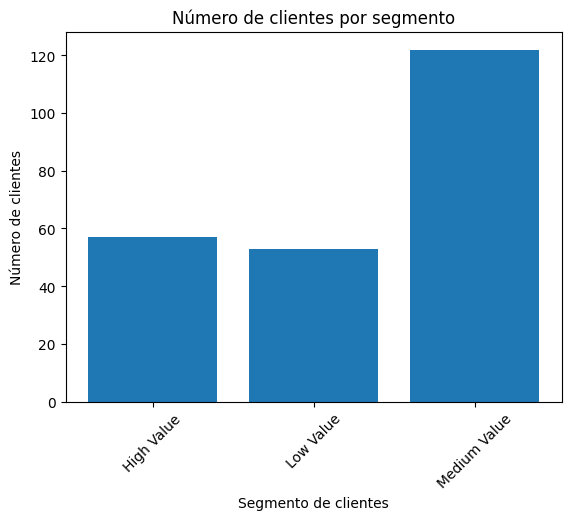

In [11]:
plt.bar(segment_channel['customer_segment'], segment_channel['customers'])
plt.title('Número de clientes por segmento')
plt.xlabel('Segmento de clientes')
plt.ylabel('Número de clientes')
plt.xticks(rotation=45)
plt.show()

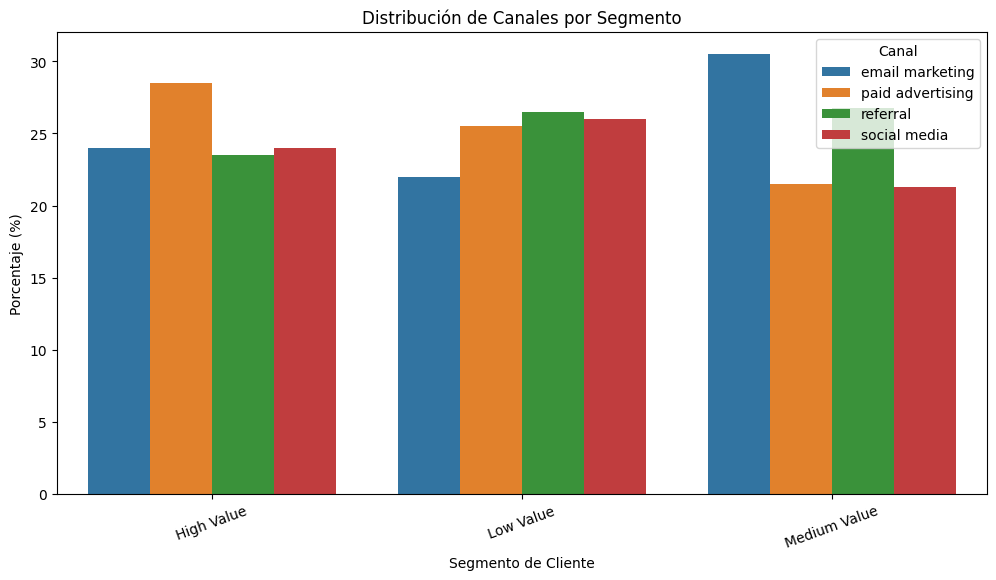

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_channel,
    x="customer_segment",
    y="percentage",
    hue="channel"
)

plt.title("Distribución de Canales por Segmento")
plt.xlabel("Segmento de Cliente")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=20)
plt.legend(title="Canal")

plt.show()


## Conclusiones y recomendaciones comerciales

El análisis de los clientes segmentados según su **Net Value (Revenue - Cost)** permite identificar diferencias importantes en el valor económico generado por cada grupo y establecer oportunidades de acción comercial.

### 1. El segmento High Value concentra los clientes de mayor valor económico

Los clientes clasificados como **High Value** presentan los niveles más altos de Net Value en todos los canales analizados. Los valores promedio se encuentran alrededor de **4.300–4.450**, mientras que los clientes Medium Value se ubican aproximadamente entre **2.680 y 2.830**, y los Low Value alrededor de **1.070–1.140**.

Esto confirma que la segmentación permite diferenciar claramente a los clientes según su contribución económica y facilita la priorización de recursos comerciales.

### 2. Los clientes Low Value representan una oportunidad de crecimiento

El segmento **Low Value no debe interpretarse únicamente como un grupo de bajo desempeño**, sino como un grupo de clientes sobre el cual se pueden desarrollar estrategias específicas para incrementar su valor.

La diferencia entre Low Value y High Value es considerable en todos los canales. Por ejemplo, los clientes Low Value presentan un Net Value promedio cercano a **1.100**, mientras que los High Value superan los **4.300**.

Por lo tanto, existe un espacio importante para desarrollar estrategias de **upselling, cross-selling, aumento de frecuencia de compra, ofertas personalizadas y campañas de reactivación**, dependiendo del comportamiento individual de cada cliente.

### 3. El costo por canal no explica las diferencias entre segmentos

Un hallazgo relevante es que el **costo asociado a cada canal permanece constante independientemente del segmento de cliente**. Por ejemplo, el costo promedio es aproximadamente:

* Email Marketing: **5,25**
* Paid Advertising: **30,45**
* Referral: **8,32**
* Social Media: **9,55**

Esto indica que las diferencias observadas en Net Value entre High, Medium y Low Value **no están explicadas por un mayor costo dentro del mismo canal**, sino principalmente por las diferencias en el Revenue generado por los clientes.

Desde una perspectiva gerencial, esto representa una oportunidad: **incrementar el valor de los clientes Low Value podría generar un impacto positivo en el resultado sin necesidad de incrementar significativamente el costo del canal de adquisición.**

### 4. La estrategia debe enfocarse en el cliente, no solamente en el canal

Los resultados muestran que los clientes Low Value aparecen en todos los canales. Por esta razón, no sería adecuado concluir que un canal específico es responsable de generar clientes de bajo valor.

La estrategia comercial debería utilizar el **canal como una dimensión adicional de análisis**, pero priorizar las características y comportamiento individual de cada cliente.

Por ejemplo, un cliente Low Value adquirido mediante Referral podría requerir una estrategia diferente a un cliente Low Value adquirido mediante Paid Advertising, aun cuando ambos pertenezcan al mismo segmento.

### 5. Existe una oportunidad de optimización del Customer Lifetime Value

La segmentación permite pasar de una estrategia comercial generalizada a una estrategia basada en el valor económico del cliente.

Una posible estrategia sería:

| Segmento         | Objetivo                 | Estrategia                                                               |
| ---------------- | ------------------------ | ------------------------------------------------------------------------ |
| **High Value**   | Retener y aumentar valor | Fidelización, beneficios exclusivos, cross-selling y prevención de churn |
| **Medium Value** | Incrementar valor        | Upselling, cross-selling y aumento de frecuencia de compra               |
| **Low Value**    | Desarrollar potencial    | Reactivación, ofertas personalizadas y campañas de conversión            |

De esta manera, los recursos comerciales pueden concentrarse en aquellos clientes donde existe una mayor oportunidad de generar valor incremental.

### 6. Recomendación gerencial

El principal hallazgo del análisis es que **la oportunidad no está necesariamente en reducir el costo de adquisición, sino en aumentar el valor generado por los clientes que ya fueron adquiridos**.

Dado que los costos por canal son relativamente independientes del segmento, una estrategia de profundización comercial sobre los clientes Low Value puede representar una oportunidad para mejorar la rentabilidad.

Por esta razón, se recomienda utilizar el dashboard como una herramienta de **identificación y priorización de clientes**, permitiendo a los equipos comerciales seleccionar clientes Low Value, analizar su Revenue, Cost, Net Value, Conversion Rate y canal de adquisición, y posteriormente definir acciones comerciales específicas.

En una siguiente etapa, esta metodología podría evolucionar hacia un modelo de **Customer Value Prediction**, que permita identificar qué clientes Low Value presentan mayor probabilidad de incrementar su valor y, por tanto, dónde debería concentrarse el esfuerzo comercial.
